## Projet Deep Learning II - DNN
Notebook nettoyé et réorganisé par actions : imports, préparation des données, configuration et expérimentations.

### 0) Imports

In [12]:
from DNN import DNN
from DBN import DBN
from RBM import RBM
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets

### 1) Préparation des données

In [13]:
# similar to transforms.PILToTensor() but binarizes the image
from torchvision.utils import  _log_api_usage_once
from torchvision.transforms import functional as F

class PILToBinTensor:
    """Convert a PIL Image to a tensor of the same type - this does not scale values.

    This transform does not support torchscript.

    Converts a PIL Image (H x W x C) to a Tensor of shape (C x H x W).
    """

    def __init__(self) -> None:
        _log_api_usage_once(self)

    def __call__(self, pic):
        """
        .. note::

            A deep copy of the underlying array is performed.

        Args:
            pic (PIL Image): Image to be converted to tensor.

        Returns:
            Tensor: Converted image.
        """
        tensor = F.pil_to_tensor(pic)
        tensor[tensor <= 127] = 0
        tensor[tensor > 127] = 1
        return tensor

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}()"

In [15]:
# MNIST Dataset from yann.lecun.com
mnist_trainset = datasets.MNIST(root='./data/', train=True, transform=PILToBinTensor(), download=True)
mnist_testset = datasets.MNIST(root='./data/', train=False, transform=PILToBinTensor(), download=False)

#create data loader
max_mnist_size = 60000
mnist_trainset_reduced = torch.utils.data.random_split(mnist_trainset, [max_mnist_size, len(mnist_trainset)-max_mnist_size])[0]
mnist_train_loader = torch.utils.data.DataLoader(mnist_trainset_reduced, batch_size=batch_size, shuffle=True,drop_last=True)

# download test dataset
max_mnist_size = 10000
mnist_testset_reduced = torch.utils.data.random_split(mnist_testset, [max_mnist_size, len(mnist_testset)-max_mnist_size])[0]
mnist_test_loader = torch.utils.data.DataLoader(mnist_testset_reduced, batch_size=batch_size, shuffle=True,drop_last=True)

In [16]:
n_rows = mnist_trainset_reduced.dataset.data.shape[1]
n_cols = mnist_trainset_reduced.dataset.data.shape[2]
n_channels = 1
n_pixels = n_rows*n_cols
classification_size = 10
img_shape = (n_rows, n_cols, n_channels)

In [17]:
# Unpack training data and labels
train_data, train_labels, train_clear_label = [], [], []
for data, label in mnist_train_loader:
    train_data.append(data.reshape(-1, n_rows * n_cols * n_channels))
    train_labels.append(torch.nn.functional.one_hot(label, num_classes=classification_size))
    train_clear_label.append(label)
train_data = torch.cat(train_data).numpy()
train_labels = torch.cat(train_labels).numpy()
train_clear_label = torch.cat(train_clear_label).numpy()

# Unpack test data and labels
test_data, test_labels, test_clear_label = [], [], []
for data, label in mnist_test_loader:
    test_data.append(data.reshape(-1, n_rows * n_cols * n_channels))
    test_labels.append(torch.nn.functional.one_hot(label, num_classes=classification_size))
    test_clear_label.append(label)
test_data = torch.cat(test_data).numpy()
test_labels = torch.cat(test_labels).numpy()
test_clear_label = torch.cat(test_clear_label).numpy()

### 2) Configuration d'entraînement

In [29]:
num_iterations_mnist = 50
num_iterations = 15
batch_size = 24
learning_rate = 0.05

### 3) Expérimentations
#### 3.1 Variation du nombre de couches

In [30]:
n_couches = [1, 3, 5, 7]
dnn_pretrain_train_error = []
dnn_pretrain_test_error = []
dnn_random_train_error = []
dnn_random_test_error = []

train_samples = 10000
test_samples = 2000

train_perm = np.random.permutation(len(train_data))[:train_samples]
test_perm = np.random.permutation(len(test_data))[:test_samples]

train_data_perm = train_data[train_perm]
test_data_perm = test_data[test_perm]

train_labels_perm = train_labels[train_perm]
test_labels_perm = test_labels[test_perm]

train_clear_label_perm = train_clear_label[train_perm]
test_clear_label_perm = test_clear_label[test_perm]


for n_hidden_layers in n_couches:
    couches_dnn = [n_pixels] + [200] * n_hidden_layers

    dnn_pretrain = DNN()
    dnn_pretrain.init_DNN(couches_dnn, classification_size)
    dnn_pretrain.pretrain_DNN(train_data_perm, num_iterations, learning_rate, batch_size)
    dnn_pretrain.retropropagation(num_iterations_mnist, learning_rate, batch_size, train_data_perm, train_labels_perm)
    dnn_pretrain_train_error.append(dnn_pretrain.test_DNN(train_data_perm, train_clear_label_perm))
    dnn_pretrain_test_error.append(dnn_pretrain.test_DNN(test_data_perm, test_clear_label_perm))

    dnn_random = DNN()
    dnn_random.init_DNN(couches_dnn, classification_size)
    dnn_random.retropropagation(num_iterations_mnist, learning_rate, batch_size, train_data_perm, train_labels_perm)
    dnn_random_train_error.append(dnn_random.test_DNN(train_data_perm, train_clear_label_perm))
    dnn_random_test_error.append(dnn_random.test_DNN(test_data_perm, test_clear_label_perm))

Epoch: 0, Error: 0.048603149145855715
Epoch: 1, Error: 0.045091683919315714
Epoch: 2, Error: 0.0421517006265169
Epoch: 3, Error: 0.040185230192394096
Epoch: 4, Error: 0.03937440894116906
Epoch: 5, Error: 0.038146723870419445
Epoch: 6, Error: 0.03755453469332581
Epoch: 7, Error: 0.03742166621164594
Epoch: 8, Error: 0.03665586886730121
Epoch: 9, Error: 0.036005369260585916
Epoch: 10, Error: 0.03588306274181148
Epoch: 11, Error: 0.03525151158719118
Epoch: 12, Error: 0.035228150127181466
Epoch: 13, Error: 0.03437848423495884
Epoch: 14, Error: 0.03446697512855711
Final L2 Loss: 0.03446697512855711
Loss at epoch 0 : 0.903
Loss at epoch 1 : 0.658
Loss at epoch 2 : 0.556
Loss at epoch 3 : 0.498
Loss at epoch 4 : 0.459
Loss at epoch 5 : 0.431
Loss at epoch 6 : 0.409
Loss at epoch 7 : 0.392
Loss at epoch 8 : 0.378
Loss at epoch 9 : 0.366
Loss at epoch 10 : 0.355
Loss at epoch 11 : 0.346
Loss at epoch 12 : 0.338
Loss at epoch 13 : 0.330
Loss at epoch 14 : 0.323
Loss at epoch 15 : 0.317
Loss at ep

##### Visualisation des résultats (3.1)

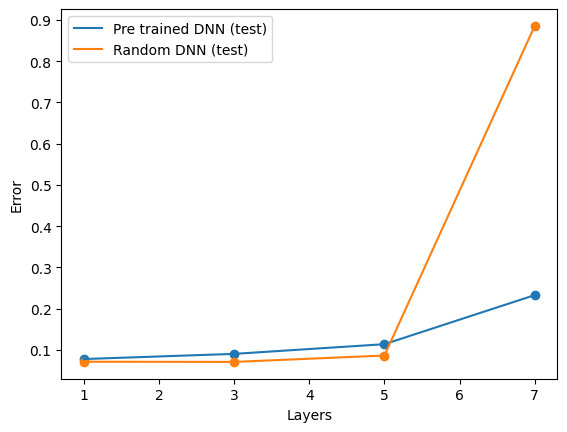

Erreurs train (pré-entraîné): [0.0608 0.0644 0.087  0.2237]
Erreurs test  (pré-entraîné): [0.078  0.0905 0.114  0.233 ]
Erreurs train (aléatoire): [0.0263 0.022  0.0336 0.8901]
Erreurs test  (aléatoire): [0.0715 0.071  0.0865 0.8855]


In [32]:
plt.plot(n_couches, dnn_pretrain_test_error, label="Pre trained DNN (test)")
plt.scatter(n_couches, dnn_pretrain_test_error)
plt.plot(n_couches, dnn_random_test_error, label="Random DNN (test)")
plt.scatter(n_couches, dnn_random_test_error)
plt.xlabel("Layers")
plt.ylabel("Error")
plt.legend()
plt.show()

print("Erreurs train (pré-entraîné):", np.round(dnn_pretrain_train_error, 4))
print("Erreurs test  (pré-entraîné):", np.round(dnn_pretrain_test_error, 4))
print("Erreurs train (aléatoire):", np.round(dnn_random_train_error, 4))
print("Erreurs test  (aléatoire):", np.round(dnn_random_test_error, 4))

#### 3.2 Variation du nombre de neurones par couche

In [33]:
n_neurones = [100, 300, 500, 700]
dnn_pretrain_train_error = []
dnn_pretrain_test_error = []
dnn_random_train_error = []
dnn_random_test_error = []

train_samples = 10000
test_samples = 2000

train_perm = np.random.permutation(len(train_data))[:train_samples]
test_perm = np.random.permutation(len(test_data))[:test_samples]

train_data_perm = train_data[train_perm]
test_data_perm = test_data[test_perm]

train_labels_perm = train_labels[train_perm]
test_labels_perm = test_labels[test_perm]

train_clear_label_perm = train_clear_label[train_perm]
test_clear_label_perm = test_clear_label[test_perm]


for n_neurone in n_neurones:
    couches_dnn = [n_pixels, n_neurone, n_neurone]

    dnn_pretrain = DNN()
    dnn_pretrain.init_DNN(couches_dnn, classification_size)
    dnn_pretrain.pretrain_DNN(train_data_perm, num_iterations, learning_rate, batch_size)
    dnn_pretrain.retropropagation(num_iterations_mnist, learning_rate, batch_size, train_data_perm, train_labels_perm)
    dnn_pretrain_train_error.append(dnn_pretrain.test_DNN(train_data_perm, train_clear_label_perm))
    dnn_pretrain_test_error.append(dnn_pretrain.test_DNN(test_data_perm, test_clear_label_perm))

    dnn_random = DNN()
    dnn_random.init_DNN(couches_dnn, classification_size)
    dnn_random.retropropagation(num_iterations_mnist, learning_rate, batch_size, train_data_perm, train_labels_perm)
    dnn_random_train_error.append(dnn_random.test_DNN(train_data_perm, train_clear_label_perm))
    dnn_random_test_error.append(dnn_random.test_DNN(test_data_perm, test_clear_label_perm))

Epoch: 0, Error: 0.05129015109912494
Epoch: 1, Error: 0.04857658486610159
Epoch: 2, Error: 0.047229734002635616
Epoch: 3, Error: 0.04614434310891371
Epoch: 4, Error: 0.04566296758030024
Epoch: 5, Error: 0.045052196455713935
Epoch: 6, Error: 0.04458233390187449
Epoch: 7, Error: 0.044542336904808744
Epoch: 8, Error: 0.043992338315687315
Epoch: 9, Error: 0.04347920838969746
Epoch: 10, Error: 0.04259655636147326
Epoch: 11, Error: 0.04221494952273438
Epoch: 12, Error: 0.04168260432163599
Epoch: 13, Error: 0.04151499726785203
Epoch: 14, Error: 0.04121844421367368
Final L2 Loss: 0.04121844421367368
Epoch: 0, Error: 0.019288136636874086
Epoch: 1, Error: 0.014193515308350151
Epoch: 2, Error: 0.01314794152174201
Epoch: 3, Error: 0.011867223861528817
Epoch: 4, Error: 0.011941261729068441
Epoch: 5, Error: 0.011213087377734072
Epoch: 6, Error: 0.011028979862584401
Epoch: 7, Error: 0.010727498412147894
Epoch: 8, Error: 0.011075592919499022
Epoch: 9, Error: 0.010731044246689088
Epoch: 10, Error: 0.01

##### Visualisation des résultats (3.2)

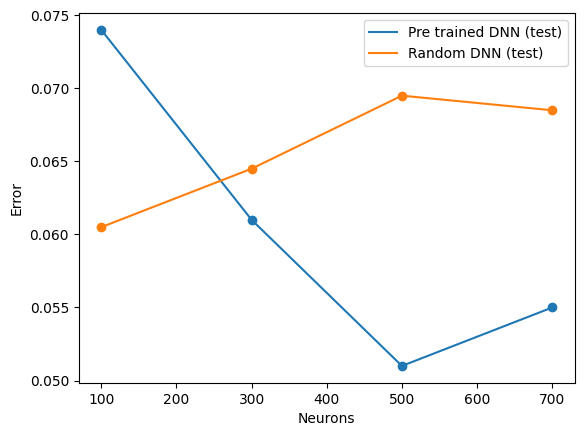

Erreurs train (pré-entraîné): [0.068  0.0497 0.0409 0.0437]
Erreurs test  (pré-entraîné): [0.074 0.061 0.051 0.055]
Erreurs train (aléatoire): [0.0224 0.0188 0.0262 0.016 ]
Erreurs test  (aléatoire): [0.0605 0.0645 0.0695 0.0685]


In [34]:
plt.plot(n_neurones, dnn_pretrain_test_error, label="Pre trained DNN (test)")
plt.scatter(n_neurones, dnn_pretrain_test_error)
plt.plot(n_neurones, dnn_random_test_error, label="Random DNN (test)")
plt.scatter(n_neurones, dnn_random_test_error)
plt.xlabel("Neurons")
plt.ylabel("Error")
plt.legend()
plt.show()

print("Erreurs train (pré-entraîné):", np.round(dnn_pretrain_train_error, 4))
print("Erreurs test  (pré-entraîné):", np.round(dnn_pretrain_test_error, 4))
print("Erreurs train (aléatoire):", np.round(dnn_random_train_error, 4))
print("Erreurs test  (aléatoire):", np.round(dnn_random_test_error, 4))

#### 3.3 Variation du nombre de données d'apprentissage

In [35]:
n_donnees_entrainement = [1000, 5000, 15000, 60000]
hidden_units = 300
dnn_pretrain_train_error = []
dnn_pretrain_test_error = []
dnn_random_train_error = []
dnn_random_test_error = []

train_perm = np.random.permutation(len(train_data))
test_perm = np.random.permutation(len(test_data))

for n_entrainement in n_donnees_entrainement:
    couches_dnn = [n_pixels, hidden_units, hidden_units]

    train_data_perm = train_data[train_perm[:n_entrainement]]
    test_data_perm = test_data[test_perm[:int(n_entrainement//5)]]

    train_labels_perm = train_labels[train_perm[:n_entrainement]]
    test_labels_perm = test_labels[test_perm[:int(n_entrainement//5)]]

    train_clear_label_perm = train_clear_label[train_perm[:n_entrainement]]
    test_clear_label_perm = test_clear_label[test_perm[:int(n_entrainement//5)]]


    dnn_pretrain = DNN()
    dnn_pretrain.init_DNN(couches_dnn, classification_size)
    dnn_pretrain.pretrain_DNN(train_data_perm, num_iterations, learning_rate, batch_size)
    dnn_pretrain.retropropagation(num_iterations_mnist, learning_rate, batch_size, train_data_perm, train_labels_perm)
    dnn_pretrain_train_error.append(dnn_pretrain.test_DNN(train_data_perm, train_clear_label_perm))
    dnn_pretrain_test_error.append(dnn_pretrain.test_DNN(test_data_perm, test_clear_label_perm))

    dnn_random = DNN()
    dnn_random.init_DNN(couches_dnn, classification_size)
    dnn_random.retropropagation(num_iterations_mnist, learning_rate, batch_size, train_data_perm, train_labels_perm)
    dnn_random_train_error.append(dnn_random.test_DNN(train_data_perm, train_clear_label_perm))
    dnn_random_test_error.append(dnn_random.test_DNN(test_data_perm, test_clear_label_perm))

Epoch: 0, Error: 0.0704728267873297
Epoch: 1, Error: 0.062213863011066316
Epoch: 2, Error: 0.057664101902712234
Epoch: 3, Error: 0.0548280776093929
Epoch: 4, Error: 0.05268304968879978
Epoch: 5, Error: 0.050789039308702474
Epoch: 6, Error: 0.04915083838401538
Epoch: 7, Error: 0.04785892921686629
Epoch: 8, Error: 0.046423102676808645
Epoch: 9, Error: 0.04549488664322457
Epoch: 10, Error: 0.04497651447526355
Epoch: 11, Error: 0.044313918463122846
Epoch: 12, Error: 0.043393355832349746
Epoch: 13, Error: 0.042713008696069324
Epoch: 14, Error: 0.04225209566580653
Final L2 Loss: 0.04225209566580653
Epoch: 0, Error: 0.011867345660603988
Epoch: 1, Error: 0.01004250480312649
Epoch: 2, Error: 0.007477442141622549
Epoch: 3, Error: 0.006294659999548786
Epoch: 4, Error: 0.006305634361319282
Epoch: 5, Error: 0.005472611591719768
Epoch: 6, Error: 0.004691199840052179
Epoch: 7, Error: 0.004142955399579117
Epoch: 8, Error: 0.00398726478620998
Epoch: 9, Error: 0.004039711738756158
Epoch: 10, Error: 0.00

##### Visualisation des résultats (3.3)

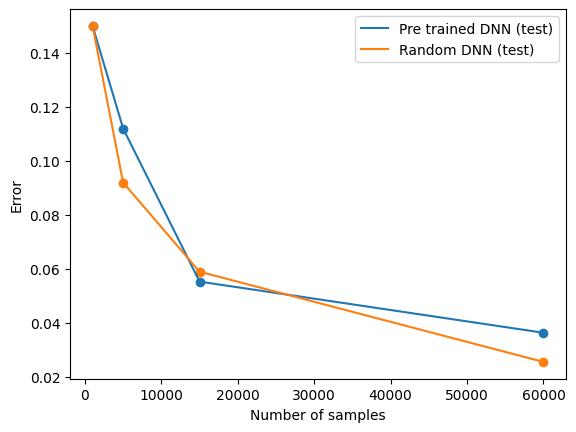

Erreurs train (pré-entraîné): [0.121  0.0894 0.0391 0.0242]
Erreurs test  (pré-entraîné): [0.15   0.112  0.0553 0.0364]
Erreurs train (aléatoire): [0.051  0.03   0.014  0.0014]
Erreurs test  (aléatoire): [0.15   0.092  0.059  0.0256]


In [36]:
plt.plot(n_donnees_entrainement, dnn_pretrain_test_error, label="Pre trained DNN (test)")
plt.scatter(n_donnees_entrainement, dnn_pretrain_test_error)
plt.plot(n_donnees_entrainement, dnn_random_test_error, label="Random DNN (test)")
plt.scatter(n_donnees_entrainement, dnn_random_test_error)
plt.xlabel("Number of samples")
plt.ylabel("Error")
plt.legend()
plt.show()

print("Erreurs train (pré-entraîné):", np.round(dnn_pretrain_train_error, 4))
print("Erreurs test  (pré-entraîné):", np.round(dnn_pretrain_test_error, 4))
print("Erreurs train (aléatoire):", np.round(dnn_random_train_error, 4))
print("Erreurs test  (aléatoire):", np.round(dnn_random_test_error, 4))

### 4) Vérification des probabilités de sortie
Observation des probabilités softmax sur quelques images du jeu d'apprentissage (après entraînement).

Epoch: 0, Error: 0.04923765877725347
Epoch: 1, Error: 0.045266931789525684
Epoch: 2, Error: 0.04316038674231154
Epoch: 3, Error: 0.04230345526510288
Epoch: 4, Error: 0.04102293407029645
Epoch: 5, Error: 0.04010611692807334
Epoch: 6, Error: 0.03979022060623557
Epoch: 7, Error: 0.03910507731702152
Epoch: 8, Error: 0.03933161928229223
Epoch: 9, Error: 0.0383004063796215
Epoch: 10, Error: 0.03840242705475939
Epoch: 11, Error: 0.03798861390074348
Epoch: 12, Error: 0.0373911197102528
Epoch: 13, Error: 0.037455691686972055
Epoch: 14, Error: 0.037121244980104245
Final L2 Loss: 0.037121244980104245
Epoch: 0, Error: 0.010870062665957119
Epoch: 1, Error: 0.008483576300073426
Epoch: 2, Error: 0.007501085178375152
Epoch: 3, Error: 0.00720428610685262
Epoch: 4, Error: 0.007047450698199143
Epoch: 5, Error: 0.006598385477115115
Epoch: 6, Error: 0.006202647707681976
Epoch: 7, Error: 0.006199935818598952
Epoch: 8, Error: 0.006213532083775511
Epoch: 9, Error: 0.005963076657823002
Epoch: 10, Error: 0.0060

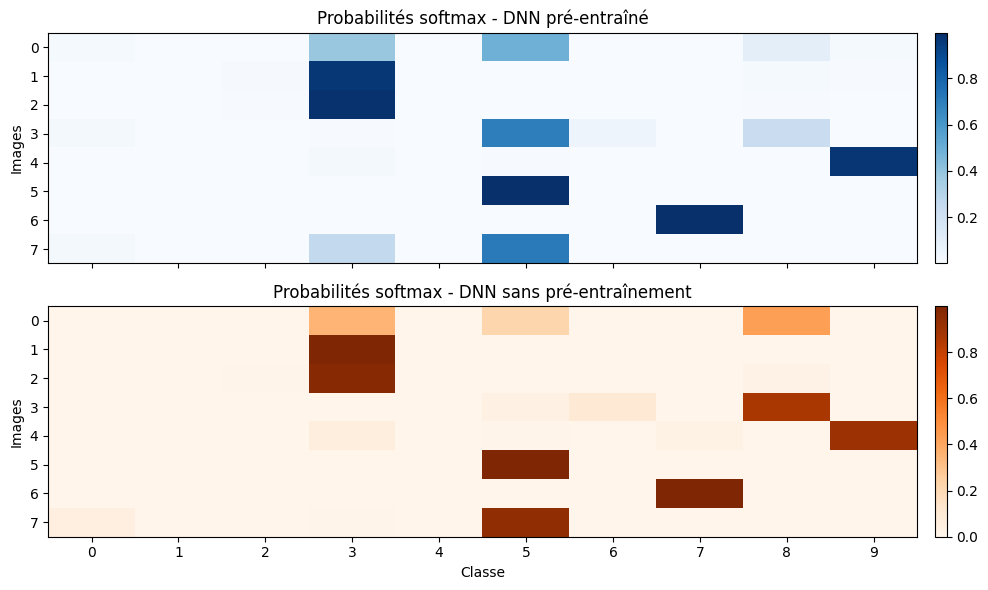

In [25]:
# Entraînement + comparaison des probabilités de sortie sur plusieurs images
couches_compare = [n_pixels, 200, 200]
n_train_compare = 10000
n_samples_compare = 8

# 1) Modèle avec pré-entraînement
dnn_pretrain_compare = DNN()
dnn_pretrain_compare.init_DNN(couches_compare, classification_size)
dnn_pretrain_compare.pretrain_DNN(train_data[:n_train_compare], num_iterations, learning_rate, batch_size)
dnn_pretrain_compare.retropropagation(
    num_iterations_mnist, learning_rate, batch_size,
    train_data[:n_train_compare], train_labels[:n_train_compare]
 )

# 2) Modèle sans pré-entraînement
dnn_random_compare = DNN()
dnn_random_compare.init_DNN(couches_compare, classification_size)
dnn_random_compare.retropropagation(
    num_iterations_mnist, learning_rate, batch_size,
    train_data[:n_train_compare], train_labels[:n_train_compare]
 )

# 3) Sélection de plusieurs images de test
np.random.seed(7)
idx = np.random.choice(len(test_data), size=n_samples_compare, replace=False)
x_cmp = test_data[idx]
y_cmp = test_clear_label[idx]

# 4) Probabilités de sortie
_, probs_pre = dnn_pretrain_compare.entree_sortie_reseau(x_cmp)
_, probs_rand = dnn_random_compare.entree_sortie_reseau(x_cmp)

pred_pre = np.argmax(probs_pre, axis=1)
pred_rand = np.argmax(probs_rand, axis=1)

print("Indices test:", idx)
print("Labels réels:", y_cmp)
print("Prédictions (pré-entraîné):", pred_pre)
print("Prédictions (sans pré-entraînement):", pred_rand)


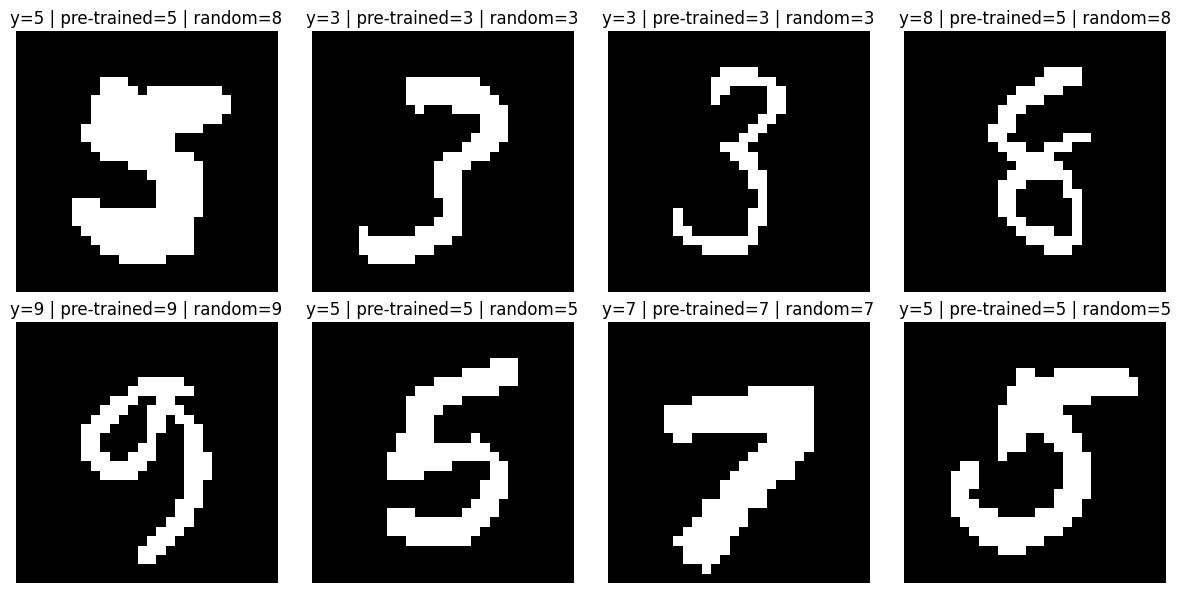

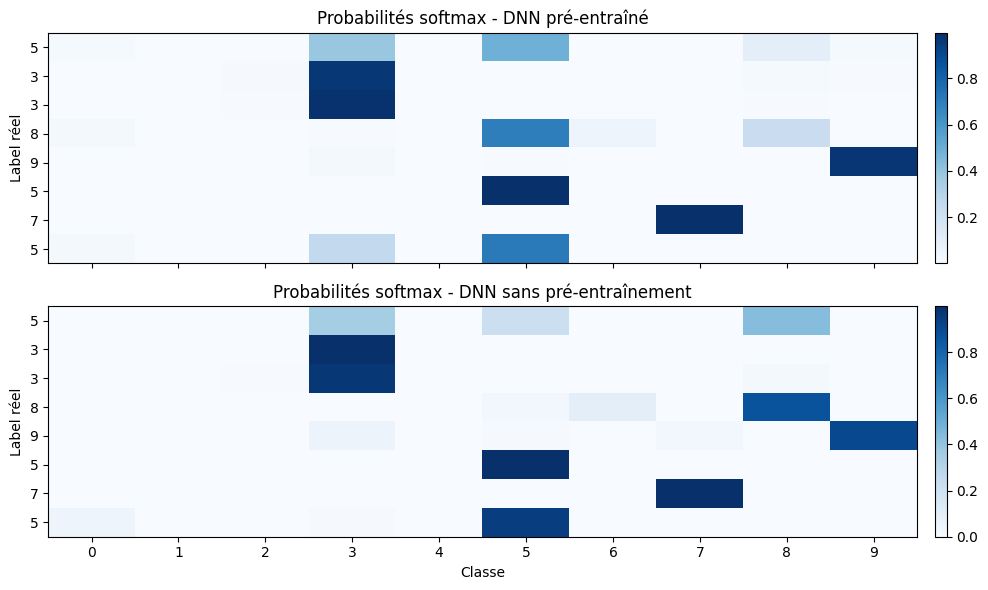

In [31]:

# 5) Visualisation des images sélectionnées
n_cols_show = 4
n_rows_show = int(np.ceil(n_samples_compare / n_cols_show))
fig, axes = plt.subplots(n_rows_show, n_cols_show, figsize=(3 * n_cols_show, 3 * n_rows_show))
axes = np.array(axes).reshape(-1)

for i in range(n_samples_compare):
    img = x_cmp[i].reshape(n_rows, n_cols)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"y={y_cmp[i]} | pre-trained={pred_pre[i]} | random={pred_rand[i]}")
    axes[i].axis('off')

for j in range(n_samples_compare, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


# 5) Visualisation comparative des probabilités (classes 0..9)

y_positions = np.arange(n_samples_compare)
y_labels = [str(int(label)) for label in y_cmp]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
im0 = axes[0].imshow(probs_pre, aspect='auto', cmap='Blues')
axes[0].set_title("Probabilités softmax - DNN pré-entraîné")
axes[0].set_ylabel("Label réel")
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(y_labels)
plt.colorbar(im0, ax=axes[0], fraction=0.02, pad=0.02)

im1 = axes[1].imshow(probs_rand, aspect='auto', cmap='Blues')
axes[1].set_title("Probabilités softmax - DNN sans pré-entraînement")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Label réel")
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(y_labels)
axes[1].set_xticks(range(classification_size))
plt.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.02)

plt.tight_layout()
plt.show()